# LINCS1000 Analysis v3

## Outline

The following pipeline combines STRINGdb protein-protein interaction (PPI) data for _Homo sapiens_ with transcriptomic data from perturbagen studies in the L1000 database:

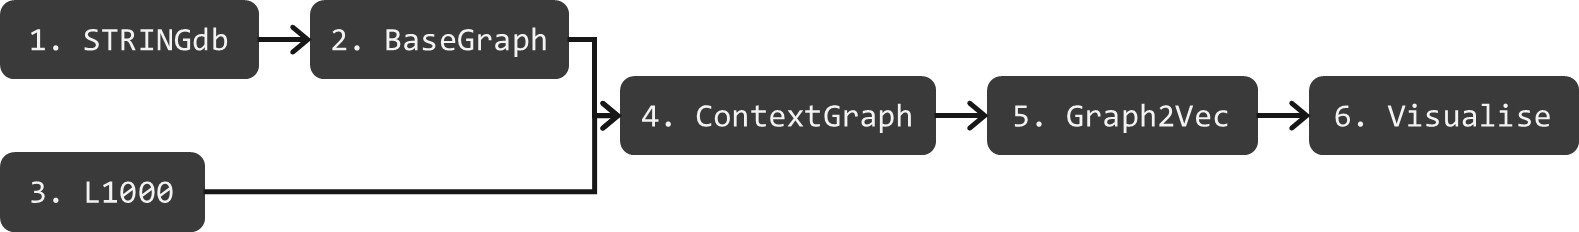

**1. STRINGdb**

- Full human PPI data from v12 of STRINGdb

**2. BaseGraph**

- A `networkx` graph object representing the edgelist defined in **1**

**3. L1000**

- Transcriptomic data for specific or all perturbagens, at 6h and 24h post-application to human cell lines

**4. ContextGraph**

- Timepoint/perturbagen/cell-line specific graphs, using transcriptomic values as node signal overlayed onto the `BaseGraph` from **2**

**5. Graph2Vec**

- Graph embedding of the outputs from **4**, undertaken in the `g2v.ipynb` notebook due to version control issues

**6. Visualise**

- Analysis and visualisation of the output from **5**, including `uMAP` dimensionality reduction

# Packages

In [ ]:
from cmapPy.pandasGEXpress import parse
import inspect
import itertools
import os
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
import pickle
import random
import re
import seaborn as sns
import umap
import warnings

# Directories

In [2]:
DATAFRAME = 'D:/DDesktop/_code/canada/lincs_analysis/dataframes/'
GRAPH_BASE = 'D:/DDesktop/_code/canada/lincs_analysis/graphs/base/'
GRAPH_PERTURBAGEN = 'D:/DDesktop/_code/canada/lincs_analysis/graphs/perturbagen/'
LINCS_SIGNATURE = 'D:/DDesktop/_code/canada/lincs_analysis/lincs/test_signatures/'
LINCS_ALL = 'D:/DDesktop/_code/canada/lincs_analysis/lincs/all_data/'
STRING = 'D:/DDesktop/_code/canada/lincs_analysis/string/'
PLOT = 'D:/DDesktop/_code/canada/lincs_analysis/plots/'

# Files

In [3]:
DF_STRING_EDGELIST = STRING + '9606.protein.physical.links.full.v12.0.txt.gz'
DF_STRING_INFO = STRING + '9606.protein.info.v12.0.txt.gz'

DF_LINCS_DATA = LINCS_ALL + 'LDS-1481_1.0.gctx'
DF_LINCS_INFO = LINCS_ALL + 'GSE92742_Broad_LINCS_sig_info.txt'
DF_LINCS_GENES = LINCS_ALL + 'GSE92742_Broad_LINCS_gene_info.txt'

# Functions

In [ ]:
def func_param_typecheck(function, *args, **kwargs) -> None:
    '''
    Checks the types of parameters for a given function based on parameter annotations.

    ### Parameters

    `function`: Any

    - The function whose parameters are being checked.

    `*args`: tuple

    - Tuple of positional parameters for given function, can be any type.

    `**kwargs` : dict

    - Dictionary of keyword arguments passed to the given function, where keys are strings and values are any type.

    ### Raises

    `TypeError`

    - Error raised if any parameter does not match its annotated type
    '''

    ## FUNCTION

    # Get function signature
    function_signature = inspect.signature(function)
    # Get function arguments
    function_arguments = function_signature.bind(*args, **kwargs)

    # Iterate through function parameters and input data types
    for parameter_name, parameter_type in function_arguments.arguments.items():
        # Get expected parameter type from annotation
        expected_type = function_signature.parameters[parameter_name].annotation
        # Check the expected type isn't empty
        if expected_type != inspect.Parameter.empty:
            # Check if parameter annotations are in a Union
            if hasattr(expected_type, '__origin__') and expected_type.__origin__ is Union:
                # Type check
                if not isinstance(parameter_type, get_args(expected_type)):
                    # Extract list of allowed types
                    allowed_types = ', '.join(etype.__name__ for etype in get_args(expected_type))
                    # Raise error
                    raise TypeError(f'Parameter \'{parameter_name}\' must be one of types: \'{allowed_types}\', ' 
                                    f'but got \'{type(parameter_type).__name__}\'')
            # Else type check single annotated type
            elif not isinstance(parameter_type, expected_type):
                # Raise error
                raise TypeError(f'Parameter \'{parameter_name}\' must be of type \'{expected_type.__name__}\', '
                                f'but got \'{type(parameter_type).__name__}\'')

def graph_save(graph: nx.Graph, graph_name: str, path: str = os.getcwd(), graphml: bool = False, report: bool = False) -> None:
    '''
    Saves a NetworkX graph object to specified location using the pickle package OR as a .gml file for downstream analysis.

    ### Parameters

    `graph`: nx.Graph

    > NetworkX graph object to be saved.

    `graph_name`: str

    > Name for saved file.

    `path`: str (default = current working directory)

    > Save location.

    ### Returns

    Pickled graph object
    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_save, graph, graph_name, path, graphml, report)

    ## FUNCTION

    # Check graphml parameter
    if graphml == False:
        # Pickle graph
        with open(f'{path}/{graph_name}.pkl', 'wb') as f:
            pickle.dump(graph, f)
    else:
        # Save graph as .gml file
        nx.write_graphml(graph, path = f'{path}/{graph_name}.gml')

    ## REPORT

    if report == True:
        # Statistics
        num_nodes = len(graph.nodes)
        num_edges = len(graph.edges)
        # Print
        print('>> graph_save')
        if graphml == False:
            print(f'NetworkX graph object w/ {num_nodes:,} nodes and {num_edges:,} edges saved to {path}/{graph_name}.pkl')
        else:
            print(f'NetworkX graph object w/ {num_nodes:,} nodes and {num_edges:,} edges saved to {path}/{graph_name}.gml')
        print()

def graph_load(path: str, graphml: bool = False, report: bool = False) -> nx.Graph:
    '''
    Loads a pickled NetworkX graph object.

    ### Parameters

    `path`: str

    > Location of the pickled graph file.

    ### Returns

    `graph`: nx.Graph

    > NetworkX graph object.
    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_load, path, graphml, report)

    ## FUNCTION

    # Check graphml parameter
    if graphml == False:
        with open(f'{path}', 'rb') as f:
            graph = pickle.load(f)
    else:
        graph = nx.read_graphml(path)
        graph = nx.relabel_nodes(graph, lambda x: int(x))

    ## REPORT

    if report == True:
        # Statistics
        num_nodes = graph.number_of_nodes()
        num_edges = graph.number_of_edges()
        # Print
        print('>> graph_load')
        if graphml == False:
            print(f'Pickled NetworkX graph object with {num_nodes:,} nodes and {num_edges:,} edges loaded from {path}')
        else:
            print(f'GraphML NetworkX graph object with {num_nodes:,} nodes and {num_edges:,} edges loaded from {path}')
        print()

    return graph


# 1. STRINGdb

## 1.1 Edgelist

- Imports the STRINGdb PPI edgelist, with associated confidence scores

In [5]:
# Load data
string_edgelist = pd.read_csv(DF_STRING_EDGELIST, compression = 'gzip', sep = ' ')
# Show data
string_edgelist.head()

,protein1,protein2,homology,experiments,experiments_transferred,database,database_transferred,textmining,textmining_transferred,combined_score
0,9606.ENSP00000000233,9606.ENSP00000257770,0,312,0,0,0,0,0,311
1,9606.ENSP00000000233,9606.ENSP00000226004,0,162,0,0,0,0,0,161
2,9606.ENSP00000000233,9606.ENSP00000434442,0,0,0,500,0,0,0,499
3,9606.ENSP00000000233,9606.ENSP00000262455,0,531,0,0,0,0,0,531
4,9606.ENSP00000000233,9606.ENSP00000303145,0,0,0,500,0,0,0,499


## 1.2 Protein Info

- Imports the STRINGdb protein information data table

In [6]:
# Load data
string_info = pd.read_csv(DF_STRING_INFO, compression = 'gzip', sep = '\t')
# Show data
string_info.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


## 1.3 `df_string`

- Merges STRINGdb edgelist and protein information tables

In [7]:
# Define variables
source_protein_column = 'protein1'
target_protein_column = 'protein2'
score_column = 'combined_score'
protein_id_column = '#string_protein_id'
taxon_id = '9606.'

In [8]:
# Copy edgelist
df_string = string_edgelist.copy(deep = True)
# Isolate columns
df_string = df_string[[source_protein_column, target_protein_column, score_column]]

# Rename string_info column
string_info.rename(columns = {protein_id_column : source_protein_column}, inplace = True)
# Merge dataframes
df_string = pd.merge(df_string, string_info[[source_protein_column, 'preferred_name', 'annotation']], how = 'left', on = source_protein_column)
# Rename string_info column
string_info.rename(columns = {source_protein_column : target_protein_column}, inplace = True)
# Merge dataframes
df_string = pd.merge(df_string, string_info[[target_protein_column, 'preferred_name', 'annotation']], how = 'left', on = target_protein_column)
# Reset string_info columns
string_info.rename(columns = {target_protein_column : protein_id_column}, inplace = True)

# Rename df_string columns
old_column_names = df_string.columns
new_column_names = ['source_id', 'target_id', 'weight', 'source', 'source_annot', 'target', 'target_annot']

for old_name, new_name in zip(old_column_names, new_column_names):
    df_string.rename(columns = {old_name : new_name}, inplace = True)

# Remove taxon ID
for column in ['source_id', 'target_id']:
    df_string[column] = df_string[column].str.replace(taxon_id, '')

# Set column order
column_order = ['source', 'target', 'weight', 'source_id', 'target_id', 'source_annot', 'target_annot']
df_string = df_string[column_order]

# Save data
df_string.to_csv(DATAFRAME + 'df_string.csv', index = False)

# Show data
df_string.head()

,source,target,weight,source_id,target_id,source_annot,target_annot
0,ARF5,NT5E,311,ENSP00000000233,ENSP00000257770,ADP-ribosylation factor 5; GTP-binding protein...,5'-nucleotidase; Hydrolyzes extracellular nucl...
1,ARF5,DUSP3,161,ENSP00000000233,ENSP00000226004,ADP-ribosylation factor 5; GTP-binding protein...,Dual specificity protein phosphatase 3; Shows ...
2,ARF5,ARFGAP2,499,ENSP00000000233,ENSP00000434442,ADP-ribosylation factor 5; GTP-binding protein...,ADP-ribosylation factor GTPase-activating prot...
3,ARF5,ERP44,531,ENSP00000000233,ENSP00000262455,ADP-ribosylation factor 5; GTP-binding protein...,Endoplasmic reticulum resident protein 44; Med...
4,ARF5,TMED10,499,ENSP00000000233,ENSP00000303145,ADP-ribosylation factor 5; GTP-binding protein...,Transmembrane emp24 domain-containing protein ...


# 2. BaseGraph

## 2.1 Graph Object

- Generates a NetworkX graph object from STRINGdb data

In [9]:
# Load data
df_string = pd.read_csv(DATAFRAME + 'df_string.csv')
# Generate graph object
graph_base = nx.from_pandas_edgelist(df_string[df_string.columns[0:3]], source = 'source', target = 'target', edge_attr = 'weight')
# Save graph
graph_save(graph_base, graph_name = 'graph_base', path = GRAPH_BASE, graphml = False, report = True)

>> graph_save
NetworkX graph object w/ 18,767 nodes and 738,805 edges saved to D:/DDesktop/_code/canada/lincs_analysis/graphs/base//graph_base.pkl



## 2.2 Node Mapping

- Global node mapping is extracted to allow for standardisation in ContextGraph instances

In [10]:
# Extract unique node labels
unique_nodes = sorted(graph_base.nodes())
# Generate node map
node_map = {node : i for i, node in enumerate(unique_nodes)}

# 3. L1000

## 3.1 All Data

### 3.1.1 Signature Info

- Imports signature info dataframe
- Extracts perturbagen:name mapping
- Identifies signature IDs to be used to filter column IDs in full LINCS dataset, based on desired variables

In [65]:
warnings.filterwarnings('ignore')

# Load lincs_info
lincs_info = pd.read_csv(DF_LINCS_INFO, sep = '\t')
# Rename columns
lincs_info.rename(columns = {'pert_id' : 'perturbagen_id', 'pert_iname' : 'perturbagen_name'}, inplace = True)
lincs_info.head()

,sig_id,perturbagen_id,perturbagen_name,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
0,AML001_CD34_24H:A05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:A05
1,AML001_CD34_24H:A06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:A06
2,AML001_CD34_24H:B05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:B05|AML001_CD34_24H_X...
3,AML001_CD34_24H:B06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:B06
4,AML001_CD34_24H:BRD-A03772856:0.37037,BRD-A03772856,BRD-A03772856,trt_cp,CD34,0.37037,µM,500 nM,24,h,24 h,AML001_CD34_24H_X1_F1B10:J04|AML001_CD34_24H_X...


#### 3.1.1a Perturbagen IDs > Names

In [66]:
# Isolate columns
lincs_pert = lincs_info[['perturbagen_id', 'perturbagen_name']]
# Remove duplicates
lincs_pert.drop_duplicates(inplace = True, ignore_index = True)
# Generate mapping dictionary for later use
perturbagen_map = dict(zip(lincs_info['perturbagen_id'], lincs_info['perturbagen_name']))
# Show data
lincs_pert.head()

,perturbagen_id,perturbagen_name
0,DMSO,DMSO
1,BRD-A03772856,BRD-A03772856
2,BRD-A19037878,trichostatin-a
3,BRD-A19500257,geldanamycin
4,BRD-A34037822,KUC107191N


#### 3.1.1b Signature IDs

In [44]:
# Define filters
lincs_lines = ['HT29']
lincs_timepoints = [6, 24]
lincs_doses = [10]

# Initialise dataframe
lincs_info_filter = lincs_info[(lincs_info['cell_id'].isin(lincs_lines)) &
                               (lincs_info['pert_time'].isin(lincs_timepoints)) &
                               (lincs_info['pert_dose'].isin(lincs_doses))]

# Extract `sig_id` column as a list
list_sig_ids = lincs_info_filter['sig_id'].tolist()

print(f'{len(list_sig_ids):,} signature IDs found meeting the desired criteria')

# Show data
lincs_info_filter.head()

7,102 signature IDs found meeting the desired criteria


,sig_id,perturbagen_id,perturbagen_name,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
50538,CPC004_HT29_6H:BRD-A00546892-001-01-8:10,BRD-A00546892,biperiden,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:J19|CPC004_HT...
50539,CPC004_HT29_6H:BRD-A00993607-003-15-4:10,BRD-A00993607,alprenolol,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:E24|CPC004_HT...
50540,CPC004_HT29_6H:BRD-A01593789-001-02-3:10,BRD-A01593789,chlormadinone-acetate,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:H21|CPC004_HT...
50541,CPC004_HT29_6H:BRD-A01643550-001-03-1:10,BRD-A01643550,prednisolone-acetate,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:P13|CPC004_HT...
50542,CPC004_HT29_6H:BRD-A02006392-001-09-9:10,BRD-A02006392,nitrendipine,trt_cp,HT29,10.0,µM,10 µM,6,h,6 h,CPC004_HT29_6H_X1_B3_DUO52HI53LO:F14|CPC004_HT...


### 3.1.2 Filtered Data

In [45]:
# Define path to full data
gctx_path = LINCS_ALL + 'LDS-1481_1.0.gctx'

# Load list_filter_small only from main data
lincs_filter = parse.parse(gctx_path, cid = list_sig_ids)

# Show data
lincs_filter.data_df.head()

cid,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005_HT29_6H:BRD-A07824748-001-02-6:10,CPC004_HT29_6H:BRD-K20482099-001-01-1:10,CPC005_HT29_6H:BRD-K62929068-001-03-3:10,CPC005_HT29_6H:BRD-K43405658-001-01-8:10,CPC004_HT29_6H:BRD-K03670461-001-02-0:10,CPC004_HT29_6H:BRD-K36737713-001-01-6:10,CPC005_HT29_6H:BRD-K51223576-001-01-3:10,CPC004_HT29_6H:BRD-A14966924-001-03-0:10,CPC004_HT29_6H:BRD-K79131256-001-08-8:10,...,PCLB003_HT29_24H:BRD-K64024097-001-02-8:10,PCLB003_HT29_24H:BRD-K64106162-001-02-3:10,PCLB003_HT29_24H:BRD-K16956545-001-01-0:10,PCLB003_HT29_24H:BRD-K78431006-001-05-2:10,PCLB003_HT29_24H:BRD-K63828191-003-23-0:10,PCLB003_HT29_24H:BRD-K93754473-001-17-7:10,PCLB003_HT29_24H:BRD-A52530684-003-01-7:10,PCLB003_HT29_24H:BRD-A75409952-001-01-6:10,PCLB003_HT29_24H:BRD-K04466929-001-05-1:10,PCLB003_HT29_24H:BRD-K17953061-001-10-1:10
rid,,,,,,,,,,,,,,,,,,,,,
5720,-2.999525,-0.623000,0.141888,-0.752267,0.380861,0.076565,-0.749507,-0.284185,0.664252,-0.007322,...,-1.151560,-0.000140,0.589545,-4.135498,-1.515962,-0.059089,2.775635,1.046220,2.3866,0.1313
466,-1.922989,-1.483600,-0.004969,-1.476633,0.828392,0.913175,-0.654432,0.067755,0.684563,1.565995,...,0.390024,0.443335,0.784108,0.183998,-0.215364,1.981584,-1.622547,0.435221,-0.3456,-1.8265
6009,-0.742801,-0.406733,-0.614206,-3.505600,0.381193,0.356511,-0.324873,-0.300248,0.563278,1.232050,...,-0.415272,-0.182099,0.496713,0.417429,2.301637,-0.266856,-2.440649,-0.030544,0.3245,1.5535
2309,-1.567428,0.373000,0.258819,0.750733,-0.013309,-0.172938,-0.571196,0.091755,0.042603,-1.011316,...,0.054832,-0.706762,-0.519995,-0.955052,0.773697,-0.423104,-2.262421,0.163010,0.2551,-2.9476
387,-2.488176,-0.959167,0.737944,-1.150100,-0.292709,-1.357093,0.885794,-0.627101,-0.029998,-0.127312,...,0.611129,0.537418,0.410376,-1.394473,1.186869,-0.120520,-0.581043,-1.971128,-0.7342,-0.3201


### 3.1.3 Gene Info

In [46]:
# Load gene info data
lincs_genes = pd.read_csv(DF_LINCS_GENES, sep = '\t')
# Rename columns
lincs_genes.rename(columns = {'pr_gene_id' : 'rid', 'pr_gene_symbol' : 'gene_name', 'pr_gene_title' : 'gene_desc'}, inplace = True)
# Show data
lincs_genes.head()

,rid,gene_name,gene_desc,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


### 3.1.4 `df_lincs`

In [47]:
# Initialise df_lincs
df_lincs = lincs_filter.data_df

# Get column names
#meta_columns = df_lincs.columns.difference(['rid'], sort=False)
meta_columns = list(df_lincs.columns)
# Initialise df_meta
df_meta = pd.DataFrame(meta_columns, columns = ['original_column'])
# Copy original_col
df_meta['metadata'] = df_meta['original_column']
# Extract perturbagen IDs
df_meta['metadata'] = df_meta['metadata'].str.replace(r'-(?:[^-]+-){2}[^-]+(?=:\d+$)', '', regex=True)
# Split metadata
df_meta[['data', 'perturbagen_id', 'dose']] = df_meta['metadata'].str.split(':', expand = True)
# Split `data` column
df_meta[['dataset', 'cell_line', 'timepoint']] = df_meta['data'].str.split('_', expand = True)
# Drop columns
df_meta.drop(columns = ['metadata', 'data'], inplace = True)
# Map perturbagen names
df_meta['perturbagen_name'] = df_meta['perturbagen_id'].map(perturbagen_map)

# Reset df_lincs index
df_lincs.reset_index(inplace = True)
# Assert datatypes
df_lincs['rid'] = df_lincs['rid'].astype(int)
lincs_genes['rid'] = lincs_genes['rid'].astype(int)
# Merge with df_genes
df_lincs = pd.merge(df_lincs, lincs_genes[['rid', 'gene_name', 'gene_desc']], how = 'left', on = 'rid')

# # Melt just the gene expression values
df_lincs = df_lincs.melt(id_vars=['rid', 'gene_name', 'gene_desc'], value_vars = meta_columns, var_name = 'original_column', value_name = 'value')

# Merge df_meta with df_expr
df_lincs = pd.merge(df_lincs, df_meta, how = 'left', on = 'original_column')

# Reorder columns
df_lincs = df_lincs[['original_column', 'dataset', 'cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'rid', 'gene_name', 'gene_desc', 'value']]

# Rename columns
df_lincs.rename(columns = {'rid' : 'gene_id', 'value' : 'dexp'}, inplace = True)

# # Set datatypes
# for column in ['cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint']:
#     df_lincs[column] = df_lincs[column].astype('category')

# Save data as pickle object
with open(DATAFRAME + 'df_lincs.pkl', 'wb') as f:
    pickle.dump(df_lincs, f)

# Show data
df_lincs.head()

,original_column,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,dexp
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,5720,PSME1,proteasome activator subunit 1,-2.999525
1,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,466,ATF1,activating transcription factor 1,-1.922989
2,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,6009,RHEB,Ras homolog enriched in brain,-0.742801
3,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,2309,FOXO3,forkhead box O3,-1.567428
4,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,387,RHOA,ras homolog family member A,-2.488176


### 3.1.5 Gene Expression UMAP

In [5]:
# Load df_lincs
with open(DATAFRAME + 'df_lincs.pkl', 'rb') as f:
    df_lincs = pickle.load(f)

# Show data
df_lincs.head()

,original_column,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,dexp
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,5720,PSME1,proteasome activator subunit 1,-2.999525
1,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,466,ATF1,activating transcription factor 1,-1.922989
2,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,6009,RHEB,Ras homolog enriched in brain,-0.742801
3,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,2309,FOXO3,forkhead box O3,-1.567428
4,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,387,RHOA,ras homolog family member A,-2.488176


In [47]:
# Get number of unique perturbagen_ids
unique_perturbagens = len(pd.unique(df_lincs['perturbagen_id']))
# Check how many perturbagens have data for both timepoints in HT29
# Step 1: Group by pert_id and count unique timepoints
pert_counts = df_lincs.groupby('perturbagen_id')['timepoint'].nunique()
# Step 2: Filter for pert_ids with both 6h and 24h
pert_ids_both_timeponts = pert_counts[pert_counts == 2].index.tolist()
print(f'{len(pert_ids_both_timeponts)}/{unique_perturbagens} perturbagens with both timepoints')

938/5108 perturbagens with both timepoints


In [103]:
n_perturbagens = 100
#unique_perturbagens = pd.unique(df_lincs['perturbagen_id']).tolist()
# Select 100 random perturbagens
list_perturbagens = random.sample(pert_ids_both_timeponts, k = n_perturbagens)
#print(list_perturbagens)
# Get 6h + 24h readings
df_umap = df_lincs[((df_lincs['timepoint'] == '6H') | (df_lincs['timepoint'] == '24H')) & (df_lincs['perturbagen_id'].isin(list_perturbagens))]
# Show data
df_umap.head()

,original_column,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,dexp
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,5720,PSME1,proteasome activator subunit 1,-2.999525
1,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,466,ATF1,activating transcription factor 1,-1.922989
2,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,6009,RHEB,Ras homolog enriched in brain,-0.742801
3,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,2309,FOXO3,forkhead box O3,-1.567428
4,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,387,RHOA,ras homolog family member A,-2.488176


In [104]:
# Initialise labelled dataframe
df_label = df_umap[['perturbagen_id', 'gene_name', 'timepoint', 'dexp']]
# Generate label column
df_label['label'] = df_label['perturbagen_id'] + '_' + df_label['timepoint']
# Show data
df_label.head()

,perturbagen_id,gene_name,timepoint,dexp,label
0,BRD-A85280935,PSME1,6H,-2.999525,BRD-A85280935_6H
1,BRD-A85280935,ATF1,6H,-1.922989,BRD-A85280935_6H
2,BRD-A85280935,RHEB,6H,-0.742801,BRD-A85280935_6H
3,BRD-A85280935,FOXO3,6H,-1.567428,BRD-A85280935_6H
4,BRD-A85280935,RHOA,6H,-2.488176,BRD-A85280935_6H


In [105]:
# Group data to average `dexp` values in the case of multiple entries
df_grouped = df_label[['label', 'gene_name', 'dexp']].groupby(by = ['label', 'gene_name']).mean()
df_grouped.reset_index(inplace = True)
df_grouped.head()

,label,gene_name,dexp
0,BRD-A09062839_24H,A1CF,-1.027954
1,BRD-A09062839_24H,A2M,-0.454518
2,BRD-A09062839_24H,A4GALT,1.360878
3,BRD-A09062839_24H,A4GNT,-0.362532
4,BRD-A09062839_24H,AAAS,0.718732


In [106]:
# Pivot table for uMAP
df_pivot = pd.pivot(df_grouped, index = 'label', columns = 'gene_name', values = 'dexp')
df_pivot.head()

gene_name,A1CF,A2M,A4GALT,A4GNT,AAAS,AACS,AADAC,AAGAB,AAK1,AAMDC,...,ZSWIM1,ZSWIM8,ZW10,ZWILCH,ZWINT,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3
label,,,,,,,,,,,,,,,,,,,,,
BRD-A09062839_24H,-1.027954,-0.454518,1.360878,-0.362532,0.718732,-0.762598,-0.226419,-0.631211,0.598480,0.259686,...,0.350067,-0.049776,-2.025835,-1.197797,0.442948,0.385975,-0.425258,-0.941174,-0.760698,-0.648174
BRD-A09062839_6H,0.782197,-0.018904,1.433238,-0.177410,-0.278606,-0.277025,0.053876,-0.401347,0.252057,0.263303,...,0.258356,0.192179,-0.123444,-0.810855,0.331772,-0.107413,0.186413,0.284802,0.105335,0.219624
BRD-A09533288_24H,-0.108287,-0.744462,-0.580984,-0.757271,-0.549038,0.239984,-0.468734,0.387370,-0.469322,-0.159029,...,-0.489007,-0.343458,0.111203,0.045924,0.016469,-0.666345,-0.231685,-0.230928,-0.633278,-0.365092
BRD-A09533288_6H,0.058444,0.009727,0.140358,-0.157231,-0.292454,0.073264,-0.215882,-0.098607,0.097541,-0.487258,...,-0.148862,-0.339342,-0.386983,0.725530,0.174492,0.014953,-0.198183,-0.096446,-0.493228,0.542618
BRD-A11483079_24H,-0.674740,0.509181,0.353719,-1.167035,1.422992,0.705344,-0.361077,-1.414166,-0.961872,0.244170,...,0.209836,-0.467151,0.333110,0.045531,0.283836,-1.078790,-0.095149,-0.190028,-0.932644,0.023075


In [107]:
# Function to normalize a row between -1 and 1
def normalize_row(row):
    max_pos = row[row > 0].max() if any(row > 0) else 1  # avoid division by zero
    max_neg = row[row < 0].min() if any(row < 0) else -1

    return row.apply(lambda x: x / max_pos if x > 0 else (x / abs(max_neg) if x < 0 else 0))

# Apply row-wise
df_normal = df_pivot.apply(normalize_row, axis=1)

# Show data
df_normal.head()

gene_name,A1CF,A2M,A4GALT,A4GNT,AAAS,AACS,AADAC,AAGAB,AAK1,AAMDC,...,ZSWIM1,ZSWIM8,ZW10,ZWILCH,ZWINT,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3
label,,,,,,,,,,,,,,,,,,,,,
BRD-A09062839_24H,-0.111719,-0.049398,0.249033,-0.039400,0.131524,-0.082880,-0.024608,-0.068601,0.109518,0.047521,...,0.064060,-0.005410,-0.220170,-0.130178,0.081057,0.070631,-0.046218,-0.102288,-0.082674,-0.070444
BRD-A09062839_6H,0.121000,-0.002586,0.221711,-0.024271,-0.038115,-0.037899,0.008334,-0.054907,0.038991,0.040731,...,0.039966,0.029729,-0.016888,-0.110930,0.051323,-0.014695,0.028837,0.044057,0.016294,0.033974
BRD-A09533288_24H,-0.029542,-0.203096,-0.158498,-0.206591,-0.149783,0.046993,-0.127875,0.075854,-0.128036,-0.043385,...,-0.133406,-0.093699,0.021776,0.008993,0.003225,-0.181785,-0.063206,-0.062999,-0.172764,-0.099601
BRD-A09533288_6H,0.022221,0.003698,0.053365,-0.065466,-0.121769,0.027855,-0.089887,-0.041057,0.037085,-0.202879,...,-0.061981,-0.141291,-0.161128,0.275849,0.066342,0.005685,-0.082517,-0.040157,-0.205365,0.206305
BRD-A11483079_24H,-0.103868,0.080717,0.056073,-0.179650,0.225578,0.111814,-0.055583,-0.217693,-0.148068,0.038707,...,0.033264,-0.071912,0.052806,0.007218,0.044995,-0.166066,-0.014647,-0.029252,-0.143569,0.003658


In [108]:
# Run uMAP on normalised data
umap_model = umap.UMAP(n_components = 2)
df_result = umap_model.fit_transform(df_normal.values)
# Convert result to dataframe
df_result = pd.DataFrame(df_result, index = df_normal.index)
# Reset index
df_result.reset_index(inplace = True)
# Expand label column
df_result[['perturbagen_id', 'timepoint']] = df_result['label'].str.split('_', expand = True)
# Drop columns
df_result.drop(columns = 'label', inplace = True)
# Map perturbagen names
df_result = pd.merge(df_result, lincs_pert, on = 'perturbagen_id', how = 'left')
# Rename columns
df_result.rename(columns = {0 : 'x', 1 : 'y'}, inplace = True)
# Show data
df_result.head()

,x,y,perturbagen_id,timepoint,perturbagen_name
0,15.561975,11.440124,BRD-A09062839,24H,amyleine
1,15.878030,11.914863,BRD-A09062839,6H,amyleine
2,18.018463,12.793205,BRD-A09533288,24H,verapamil
3,16.051643,13.879596,BRD-A09533288,6H,verapamil
4,17.065063,12.387087,BRD-A11483079,24H,dihydroobliquin


In [90]:
df_concat_normal = df_normal.reset_index()
df_concat_normal.drop(columns = 'label', inplace = True)
df_concat_normal.head()
# Check correlations between genes and umap components
df_concat = pd.concat([df_concat_normal, df_result[['x', 'y']]], axis = 1)
# Compute correlation matrix
corr_matrix = df_concat.corr()
# Check
#print(corr_matrix[['UMAP1', 'UMAP2']].sort_values(by='UMAP1', ascending=False))
#print(corr_matrix[['UMAP1', 'UMAP2']].sort_values(by='UMAP2', ascending=False))
#df_concat.head()
corr_matrix

,A1CF,A2M,A4GALT,A4GNT,AAAS,AACS,AADAC,AAGAB,AAK1,AAMDC,...,ZW10,ZWILCH,ZWINT,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3,x,y
A1CF,1.000000,0.196277,0.407643,0.644475,0.047184,0.011835,0.209607,-0.360308,0.667495,0.150835,...,-0.180758,-0.364865,-0.143135,0.651340,0.367024,0.044757,0.211112,-0.021237,0.237689,-0.600106
A2M,0.196277,1.000000,0.294786,0.309651,0.150719,-0.142714,0.053970,-0.419165,0.222817,0.224425,...,0.046181,-0.150011,0.146178,0.323818,0.294802,-0.255382,0.054758,-0.097895,0.167006,-0.366161
A4GALT,0.407643,0.294786,1.000000,0.443413,0.186953,0.096934,0.113272,-0.238324,0.446227,0.294740,...,-0.130998,-0.394934,-0.115511,0.565144,0.174511,-0.172261,0.250981,-0.066990,0.177757,-0.588897
A4GNT,0.644475,0.309651,0.443413,1.000000,0.045527,-0.158905,0.286244,-0.344427,0.761037,0.298141,...,-0.051184,-0.385335,-0.069373,0.770029,0.369470,-0.164098,0.183750,-0.024016,0.515719,-0.842984
AAAS,0.047184,0.150719,0.186953,0.045527,1.000000,0.003886,-0.028221,-0.006939,0.050400,0.084538,...,-0.090566,-0.073346,0.087854,-0.084959,-0.028284,0.066044,-0.167726,-0.010347,-0.356108,0.057464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYX,0.044757,-0.255382,-0.172261,-0.164098,0.066044,0.139185,-0.139802,0.251531,0.144772,0.074990,...,-0.268901,0.044760,-0.157907,-0.136645,-0.169871,1.000000,0.002822,0.072605,-0.252625,0.205997
ZZEF1,0.211112,0.054758,0.250981,0.183750,-0.167726,0.249383,0.062232,-0.132207,0.106051,0.167301,...,-0.004512,-0.324910,-0.159768,0.193263,0.295300,0.002822,1.000000,-0.085863,0.129663,-0.197919
ZZZ3,-0.021237,-0.097895,-0.066990,-0.024016,-0.010347,-0.054601,0.227848,0.298020,-0.080358,-0.137758,...,0.291796,0.011634,-0.102409,-0.030137,0.007062,0.072605,-0.085863,1.000000,0.067365,0.002736
x,0.237689,0.167006,0.177757,0.515719,-0.356108,-0.182300,0.291934,-0.278622,0.410143,0.074940,...,0.059397,-0.249989,-0.151955,0.532772,0.304223,-0.252625,0.129663,0.067365,1.000000,-0.570758


<Axes: xlabel='x', ylabel='y'>

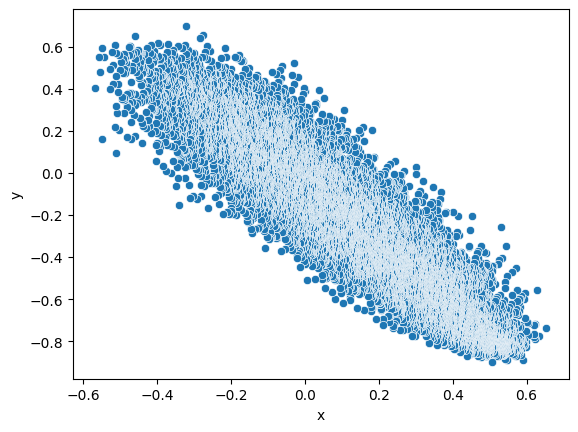

In [102]:
# Get correlation of all genes to 2 umap dimensions
df_corr = corr_matrix.iloc[:-2,:][['x', 'y']].sort_values(by='x', ascending=False)
#df_corr.head()

sns.scatterplot(df_corr, x = 'x', y = 'y')

# Show as clustermap
#sns.clustermap(df_corr, col_cluster = False, cmap = 'coolwarm', vmin = -1, vmax = 1)

In [ ]:
# List genes by biggest contribution to umap1 (umap1 vs 2 inverse correlate)
# Get top 10 contributors
# Overlay top 10 onto base graph, alongside

<Axes: xlabel='x', ylabel='y'>

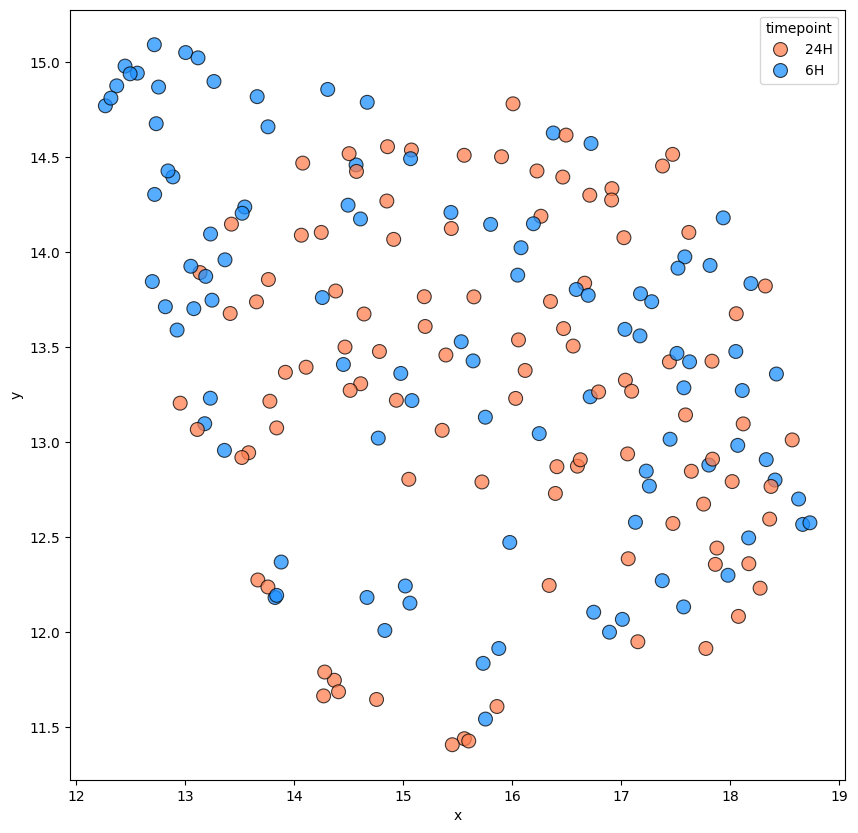

In [111]:
# Plot uMAP results

plt.figure(figsize = (10,10))

sns.scatterplot(df_result,
                x = 'x',
                y = 'y',
                hue = 'timepoint',
                palette = ['coral', 'dodgerblue'],
                s = 100,
                alpha = 0.75,
                edgecolors = 'black')

In [35]:
#list_test_columns = ['cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'gene_id', 'gene_name', 'gene_desc', 'dexp']
list_group_columns = ['perturbagen_id', 'dose', 'timepoint', 'gene_id']
for col in list_group_columns:
    if df_umap[col].dtype == 'object':
        df_umap[col] = df_umap[col].astype('category')
# df_test = df_umap[list_test_columns].groupby(by = list_group_columns).mean()
# #df_test[df_test['gene_id'] == 5720]
# df_test.reset_index(inplace = True)
list_test_columns = ['cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'gene_id', 'gene_name', 'gene_desc', 'dexp']
df_test = (
    df_umap[list_test_columns]
    .groupby(list_group_columns, as_index=False)
    .agg({'dexp': 'mean'})
)

df_test.head()

C:\Users\roman\AppData\Local\Temp\ipykernel_29316\2559007997.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(list_group_columns, as_index=False)


ValueError: Length of values (12328) does not match length of index (125942848)

In [159]:
df_test.columns

Index(['cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint',
       'gene_id', 'gene_name', 'gene_desc', 'dexp'],
      dtype='object')

In [162]:
df_test[(df_test['perturbagen_id'] == 'BRD-K85051645') & (df_test['gene_id'] == 5720)]

,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,dexp
89949,HT29,BRD-K85051645,BRD-K85051645,10,6H,5720,PSME1,proteasome activator subunit 1,0.188318


In [156]:
df_umap[(df_umap['perturbagen_id'] == 'BRD-K85051645') & (df_umap['gene_id'] == 5720)]

,original_column,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,gene_name,gene_desc,dexp
23645104,CPC007_HT29_6H:BRD-K85051645-001-01-5:10,CPC007,HT29,BRD-K85051645,BRD-K85051645,10,6H,5720,PSME1,proteasome activator subunit 1,-0.254856
39881080,CPC010_HT29_6H:BRD-K85051645-019-03-3:10,CPC010,HT29,BRD-K85051645,BRD-K85051645,10,6H,5720,PSME1,proteasome activator subunit 1,0.631493


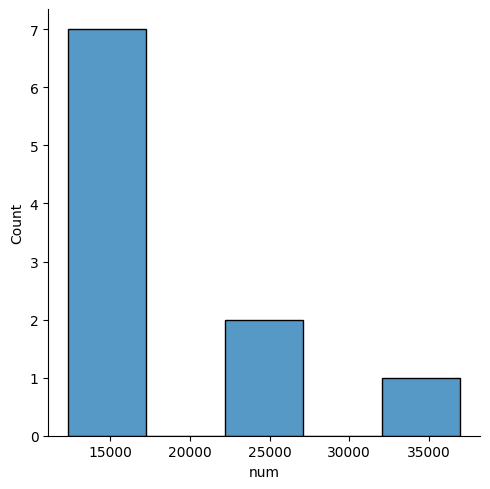

In [154]:
# Initialise list
len_pert = []

for pert in list_perturbagens:
    pert_instance = len(df_umap[df_umap['perturbagen_id'] == pert])
    len_pert.append(pert_instance)

df_test = pd.DataFrame({'pert_id' : list_perturbagens, 'num' : len_pert})
#df_test.head()
sns.displot(df_test, x = 'num')

In [155]:
df_test.head(15)

,pert_id,num
0,BRD-K90259198,12328
1,BRD-K49010888,12328
2,BRD-K10065684,12328
3,BRD-K91336023,12328
4,BRD-K85051645,24656
5,BRD-K72166146,24656
6,BRD-K53610452,12328
7,BRD-K38594532,12328
8,BRD-K21733600,36984
9,BRD-K36377456,12328


In [118]:
list_dataset = pd.unique(df_umap['dataset']).tolist()
list_timepoint = pd.unique(df_umap['timepoint']).tolist()

for dataset, timepoint in itertools.product(list_dataset, list_timepoint):

    # Slice df_umap
    df_slice = df_umap[(df_umap['dataset'] == dataset) & (df_umap['timepoint'] == timepoint)]

    # Get lists
    unique_gene_ids = pd.unique(df_slice['gene_id'])
    unique_perturbagen_ids = pd.unique(df_slice['perturbagen_id'])

    # Report
    print(f'{dataset} {timepoint}')
    print(f'{len(unique_gene_ids):,} unique gene IDs')
    print(f'{len(unique_perturbagen_ids):,} unique perturbagen IDs')
    print()

CPC004 6H
12,328 unique gene IDs
5 unique perturbagen IDs

CPC005 6H
12,328 unique gene IDs
2 unique perturbagen IDs

CPC006 6H
12,328 unique gene IDs
2 unique perturbagen IDs

CPC009 6H
12,328 unique gene IDs
3 unique perturbagen IDs

CPC008 6H
12,328 unique gene IDs
4 unique perturbagen IDs

CPC007 6H
12,328 unique gene IDs
2 unique perturbagen IDs

CPC011 6H
12,328 unique gene IDs
4 unique perturbagen IDs

CPC010 6H
12,328 unique gene IDs
5 unique perturbagen IDs

CPC012 6H
12,328 unique gene IDs
3 unique perturbagen IDs

CPC015 6H
12,328 unique gene IDs
4 unique perturbagen IDs

CPC016 6H
12,328 unique gene IDs
6 unique perturbagen IDs

CPC013 6H
12,328 unique gene IDs
3 unique perturbagen IDs

CPC014 6H
12,328 unique gene IDs
2 unique perturbagen IDs

CPC017 6H
12,328 unique gene IDs
3 unique perturbagen IDs

CPC018 6H
12,328 unique gene IDs
2 unique perturbagen IDs

CPC020 6H
12,328 unique gene IDs
3 unique perturbagen IDs

CPC019 6H
12,328 unique gene IDs
6 unique perturbagen ID

In [102]:
pd.unique(df_umap['dataset'])

array(['CPC004', 'CPC005', 'CPC008', 'CPC009', 'CPC007', 'CPC011',
       'CPC010', 'CPC012', 'CPC016', 'CPC015', 'CPC013', 'CPC014',
       'CPC018', 'CPC019', 'CPC017', 'CPC020', 'PCLB001'], dtype=object)

## 3.2 Specific Perturbagens 

# 4. ContextGraph

# 5. Graph2Vec

# 6. Visualise